# Plots Heatmap SNR + KDE pop

In [1]:
import pandas as pd

def load_snr_heatmap(csv_path):
    df = pd.read_csv(csv_path, index_col=0)
    x_vals = df.columns.astype(float).values
    y_vals = df.index.astype(float).values
    snr_grid = df.values
    return snr_grid, x_vals, y_vals

In [2]:
import joblib

def load_kde2d(kde_path):
    return joblib.load(kde_path)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from matplotlib.colors import ListedColormap, BoundaryNorm

# Dictionnaires latex et unités (à placer en global)
param_grb_names_latex = {
    'E_grb': r'$E_{\rm{GRB}}$', 'E_aft': r'$E_{\rm{aft}}$', 'theta': r'$\theta_{\rm ej}$',
    'theta_j': r'$\theta_j$', 'phi_ej': r'$\phi_{\rm{ej}}$', 'beta': r'$\beta$',
    'end_grb': r'$T_{\rm{GRB}}$', 'r': r'$d$',
    'T_90': r'$T_{90}$', 't_dec': r'$t_{\rm dec}$', 't_jet_break': r'$t_{\rm break}$'
}
param_grb_units = {
    'E_grb': 'erg', 'E_aft': 'erg', 'theta': r'$^\circ$', 'theta_j': r'$^\circ$',
    'phi_ej': r'$^\circ$', 'beta': 'c', 'end_grb': 's', 'r': 'Mpc',
    'T_90': 's', 't_dec': 's', 't_jet_break': 'day'
}

def make_discrete_cmap(snr_grid, base_cmap_name, color_range=(0, 1)):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap, BoundaryNorm

    snr_min = np.nanmin(snr_grid[snr_grid > 0])
    snr_max = np.nanmax(snr_grid)
    # On force les bornes à des puissances de 10
    exp_min = int(np.floor(np.log10(snr_min)))
    exp_max = int(np.ceil(np.log10(snr_max)))
    bounds = [10**e for e in range(exp_min, exp_max + 1)]
    # Si snr_max dépasse la dernière borne, on ajoute un bin au-dessus
    if snr_max > bounds[-1]:
        bounds.append(10**(exp_max + 1))
    n_bins = len(bounds) - 1

    # Ticks et labels à chaque puissance de 10
    ticks = [10**e for e in range(exp_min, exp_max + 1)]
    ticklabels = [f"$10^{{{e}}}$" for e in range(exp_min, exp_max + 1)]
    # fait que si 1e0 est dans les ticks, on le remplace par "1"
    if 1 in ticks:
        idx_1 = ticks.index(1)
        ticklabels[idx_1] = "1"

    base_cmap = plt.get_cmap(base_cmap_name)
    colors = base_cmap(np.linspace(*color_range, n_bins))
    discrete_cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, ncolors=n_bins)
    contour_levels = bounds

    return discrete_cmap, norm, ticks, ticklabels, bounds, contour_levels

In [37]:
def plot_snr_heatmap_with_kde_and_grbs(
    snr_csv_path, kde_path, x_key, y_key, grb_params_data, fixed_params,
    grb_markers=None, xscale='log', yscale='log', xlim=None, ylim=None
):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    import joblib
    from matplotlib.lines import Line2D

    # Charger SNR
    df = pd.read_csv(snr_csv_path, index_col=0)
    x_vals = df.columns.astype(float).values
    y_vals = df.index.astype(float).values
    
    # si x/y sont en radians, convertir en degrés pour les axes
    if x_key in ["theta", "theta_j", "phi_ej"]:
        x_vals = np.rad2deg(x_vals)
        print('key changed')
    if y_key in ["theta", "theta_j", "phi_ej"]:
        y_vals = np.rad2deg(y_vals)
        print('key changed')
    if x_key in ["r"]:
        x_vals = x_vals / 1e6  # convertir en Mpc
    if y_key in ["r"]:
        y_vals = y_vals / 1e6  # convertir en Mpc
    # print min/max de x et y pour debug
    print(f"x range: {x_vals.min()} - {x_vals.max()}")
    print(f"y range: {y_vals.min()} - {y_vals.max()}")
    
    snr_grid = df.values

    # Créer la colormap discrète et récupérer ticks/labels
    discrete_cmap, norm, ticks, ticklabels, bounds, contour_levels = make_discrete_cmap(snr_grid, 'cividis')

    # Charger la KDE
    kde = joblib.load(kde_path)
    gx = np.log10(x_vals) if xscale == 'log' else x_vals
    gy = np.log10(y_vals) if yscale == 'log' else y_vals
    X, Y = np.meshgrid(gx, gy)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z_kde = kde(positions).reshape(X.shape)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 7))
    im = ax.pcolormesh(x_vals, y_vals, snr_grid, cmap=discrete_cmap, norm=norm, shading='auto', alpha=0.92)
    cs = ax.contour(x_vals, y_vals, snr_grid, levels=contour_levels, colors='k', linewidths=1.5)
    cl1 = ax.contour(x_vals, y_vals, snr_grid, levels=[1], colors='red', linewidths=1.8, zorder=11)
    # Pas de labels inline sur les contours
    if xscale == 'log':
        ax.contour(10**X, 10**Y, Z_kde, levels=10, cmap='Greys', linewidths=1.5, alpha=0.6)
    else: 
        ax.contour(X, Y, Z_kde, levels=10, cmap='Greys', linewidths=1.5, alpha=0.6)
    # ajout de kde 99% contour
    Z_kde_flat = Z_kde.flatten()
    Z_kde_sorted = np.sort(Z_kde_flat)[::-1]
    cumsum = np.cumsum(Z_kde_sorted)
    cumsum /= cumsum[-1]
    try:
        kde_99_level = Z_kde_sorted[np.searchsorted(cumsum, 0.99)]
    except Exception:
        kde_99_level = Z_kde_sorted[-1]  # fallback

    # 2. Couleur minimale de la cmap KDE
    kde_cmap = plt.get_cmap('Greys')
    min_kde_color = kde_cmap(0.0)

    # 3. Tracé du contour
    if xscale == 'log':
        contour_99 = ax.contour(10**X, 10**Y, Z_kde, levels=[kde_99_level],
                                colors=[min_kde_color], linewidths=1.5, linestyles='-', zorder=12, alpha=0.6)
    else:
        contour_99 = ax.contour(X, Y, Z_kde, levels=[kde_99_level],
                                colors=[min_kde_color], linewidths=1.5, linestyles='-', zorder=12, alpha=0.6)

    # Points GRB colorés selon leur SNR + handles pour la légende
    if grb_markers is not None:
        legend_handles = []
        for name, params in grb_params_data.items():
            marker = grb_markers.get(name, 'o') if grb_markers else 'o'
            x_val = params[x_key]
            y_val = params[y_key]
            snr_val = params['snr']
            # Conversion angle si besoin
            if x_key in ["theta", "theta_j", "phi_ej"]:
                x_val = np.rad2deg(x_val)
            if y_key in ["theta", "theta_j", "phi_ej"]:
                y_val = np.rad2deg(y_val)
            # Couleur selon la cmap et la valeur de snr
            color = discrete_cmap(norm(snr_val))
            sc = ax.scatter(x_val, y_val, marker=marker, s=200, c=[color], edgecolors='black', zorder=10, linewidths=2)
            # Handle pour la légende
            legend_handles.append(Line2D([0], [0], marker=marker, color='w', markerfacecolor=color,
                                        markeredgecolor='black', markersize=15, linestyle='None', label=name, linewidth=2))

    ax.set_xscale(xscale)
    # larger xlabel
    ax.tick_params(axis='x', labelsize=15)
    
    ax.set_yscale(yscale)
    ax.tick_params(axis='y', labelsize=15)
    # Labels axes
    x_label = param_grb_names_latex.get(x_key, x_key)
    if x_key in param_grb_units:
        x_label += f" [{param_grb_units[x_key]}]"
    y_label = param_grb_names_latex.get(y_key, y_key)
    if y_key in param_grb_units:
        y_label += f" [{param_grb_units[y_key]}]"
    ax.set_xlabel(x_label, fontsize=17)
    ax.set_ylabel(y_label, fontsize=17)
    # Appliquer les limites si spécifiées
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    # Titre automatique avec params fixes (hors x/y)
    title_params = []
    for k, v in fixed_params.items():
        if k in [x_key, y_key]:
            continue
        name = param_grb_names_latex.get(k, k)
        unit = param_grb_units.get(k, '')
        if k in ['theta', 'theta_j', 'phi_ej']:
            val_str = f"{np.rad2deg(v):.0f}"
        elif k == 'r':
            val_str = f"{v/1e6:.1f}"
        elif k == 't_jet_break' and v >= 86400:
            val_str = f"{v/86400:.0f}"
        elif isinstance(v, float) and (v < 1e-3 or v > 1e3):
            val_str = f"{v:.1e}"
        elif k == 'beta':
            val_str = f"{v:.2f}"
        else:
            val_str = f"{v:.0f}" if isinstance(v, float) else str(v)
        title_params.append(f"{name}={val_str} {unit}")
    title = " | ".join(title_params)
    ax.set_title(title, fontsize=16, pad=20)


    cbar = fig.colorbar(im, ax=ax, ticks=ticks, pad=0.05, aspect=30)
    cbar.set_label("SNR", fontsize=20, labelpad=-10, rotation=0, y=-0.05, va='top', ha='right')
    cbar.ax.tick_params(labelsize=15)
    cbar.ax.set_yticklabels(ticklabels)
    
    for tick in cbar.ax.get_yticklabels():
            if tick.get_text() in ["$10^{0}$", "1.0", "1"]:
                tick.set_color('red')
                tick.set_text("1")

    # Légende GRB
    if grb_markers is not None:
        ax.legend(handles=legend_handles, loc='upper center', fontsize=13, frameon=False, ncol=len(legend_handles), bbox_to_anchor=(0.5, -0.15))
    plt.tight_layout()
    plt.show()
    return ax

In [5]:
grb_params_data = {
    "BOAT": {
        "E_grb": 1e55, "E_aft": 3e54, "r": 724.0 ,
        "theta_j": 0.014, "theta": np.mean([0.00094, 0.0059]), 'T_90': 600, 'snr': 3.8e-5, 't_dec': 50, 't_jet_break': 1*86400, 'beta': 0.99
    },
    "GRB 250702B": {
        "E_grb": 2.2e54, "E_aft": 8e54, "r": 7093,
        "theta_j": np.deg2rad(0.5), "theta": np.deg2rad(65), 'T_90': 25000, 'snr': 2.6e-5, 't_dec': 50, 't_jet_break': 1*86400, 'beta': 0.99 
    },
    "GRB 980425": {
        "E_grb": 6e47, "E_aft": 1e49, "r": 36.9,
        "theta_j": np.deg2rad(np.mean([18, 31])), "theta": np.deg2rad(np.mean([24, 35])), 'T_90': 30, 'snr': 6.3e-7, 't_dec': 50, 't_jet_break': 1*86400, 'beta': 0.99
    },
    "GRB 170817A": {
        "E_grb": 3e46, "E_aft": 10**52.2, "r": 40.0,
        "theta_j": 0.3, "theta": np.deg2rad(32), 'T_90': 2, 'snr': 3.8e-6, 't_dec': 50, 't_jet_break': 1*86400, 'beta': 0.99
    },
    "GRB 211211A": {
            "E_grb": 7.6e51, "E_aft": 5e52, 'r': 350.0, 'T_90': 51.37, 'theta_j': np.deg2rad(0.04),
            'theta': np.deg2rad(30), 'snr': 7.5e-4, 't_dec': 50, 't_jet_break': 1*86400, 'beta': 0.99
            }
}

fixed_params = {'E_aft': 1e52, 'E_grb': 1e50, 'r': 1e8, 'T_90': 100, 't_dec': 50, 't_jet_break': 1*86400, 'theta': np.deg2rad(10), 'beta': 0.99}


x range: 1e+45 - 1e+60
y range: 1.0 - 100000.0


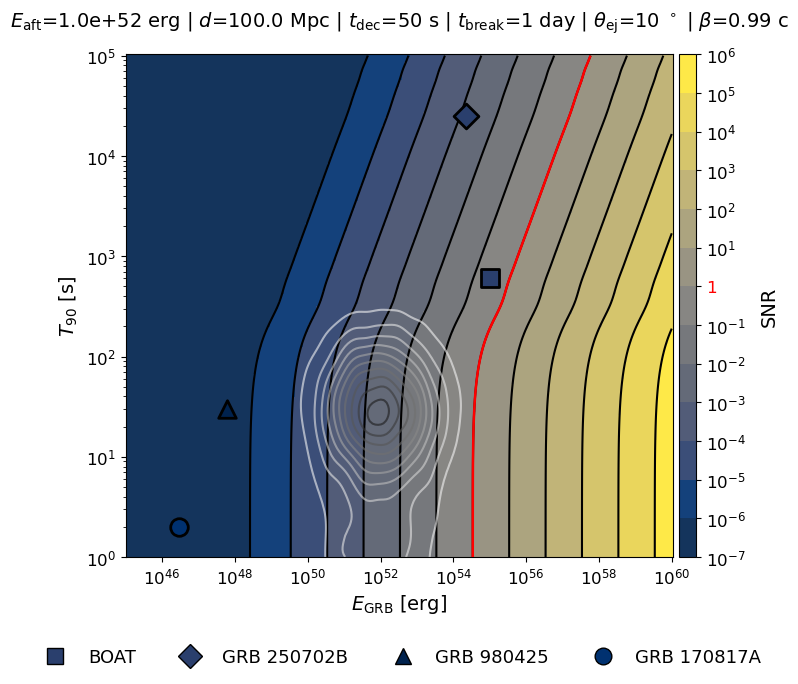

<Axes: title={'center': '$E_{\\rm{aft}}$=1.0e+52 erg | $d$=100.0 Mpc | $t_{\\rm dec}$=50 s | $t_{\\rm break}$=1 day | $\\theta_{\\rm ej}$=10 $^\\circ$ | $\\beta$=0.99 c'}, xlabel='$E_{\\rm{GRB}}$ [erg]', ylabel='$T_{90}$ [s]'>

In [6]:
plot_snr_heatmap_with_kde_and_grbs(
    snr_csv_path="results_snr_heatmap_grb_newmodel/SNR_heatmap_E_grb_T_90.csv",
    kde_path="grb_pop_kde2d/E_grb_T90_kde2d.joblib",
    x_key="E_grb", y_key="T_90",
    grb_params_data=grb_params_data,
    fixed_params=fixed_params,
    grb_markers={"BOAT": 's', "GRB 250702B": 'D', "GRB 980425": '^', "GRB 170817A": 'o'}
)

x range: 1.0 - 100000.0
y range: 1e+46 - 3.1622776601683795e+55


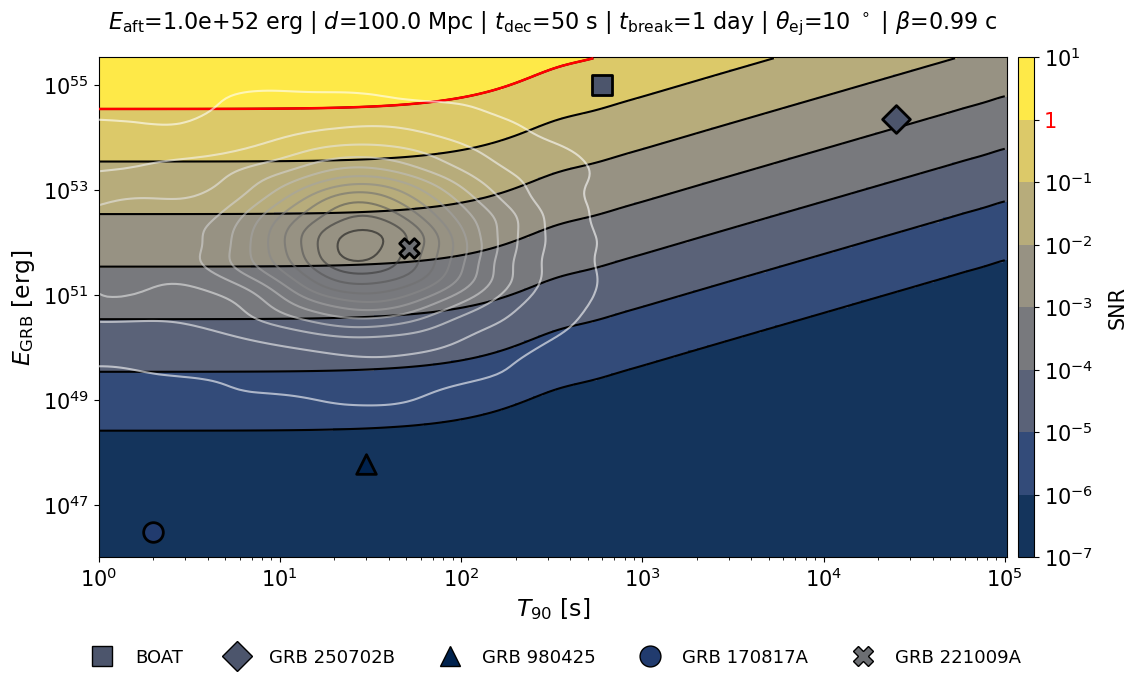

<Axes: title={'center': '$E_{\\rm{aft}}$=1.0e+52 erg | $d$=100.0 Mpc | $t_{\\rm dec}$=50 s | $t_{\\rm break}$=1 day | $\\theta_{\\rm ej}$=10 $^\\circ$ | $\\beta$=0.99 c'}, xlabel='$T_{90}$ [s]', ylabel='$E_{\\rm{GRB}}$ [erg]'>

In [ ]:
fixed_params = {'E_aft': 1e52, 'r': 1e8, 'T_90': 100, 't_dec': 50, 't_jet_break': 1*86400, 'theta': np.deg2rad(10), 'beta': 0.99}

plot_snr_heatmap_with_kde_and_grbs(
    snr_csv_path="results_snr_heatmap_grb_newmodel/SNR_heatmap_T_90_E_grb.csv",
    kde_path="grb_pop_kde2d/T90_E_grb_kde2d.joblib",
    x_key="T_90", y_key="E_grb",
    grb_params_data=grb_params_data,
    fixed_params=fixed_params,
    grb_markers={"BOAT": 's', "GRB 250702B": 'D', "GRB 980425": '^', "GRB 170817A": 'o', "GRB 211211A": 'X'},
)

x range: 1e+46 - 3.1622776601683795e+55
y range: 1e+48 - 3.1622776601683795e+55


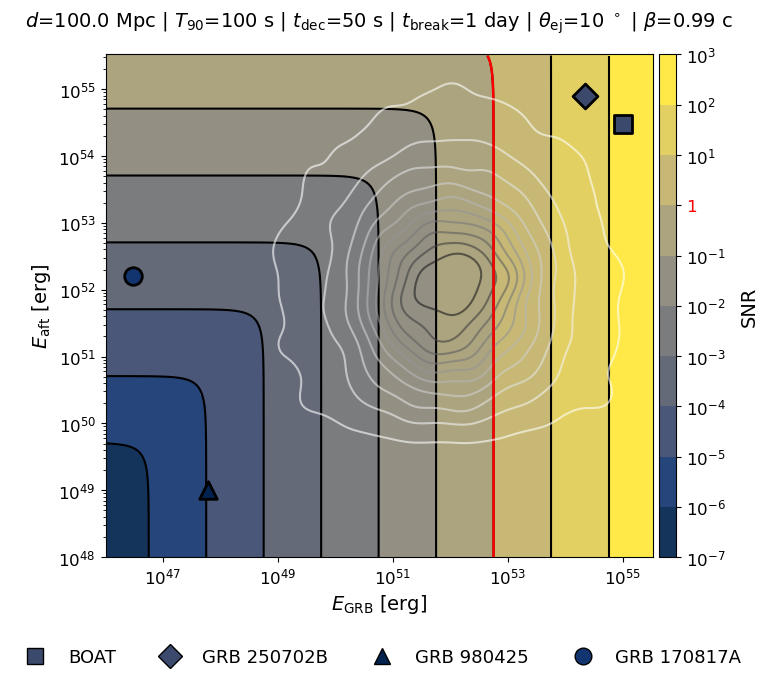

<Axes: title={'center': '$d$=100.0 Mpc | $T_{90}$=100 s | $t_{\\rm dec}$=50 s | $t_{\\rm break}$=1 day | $\\theta_{\\rm ej}$=10 $^\\circ$ | $\\beta$=0.99 c'}, xlabel='$E_{\\rm{GRB}}$ [erg]', ylabel='$E_{\\rm{aft}}$ [erg]'>

In [18]:
plot_snr_heatmap_with_kde_and_grbs(
    snr_csv_path="results_snr_heatmap_grb_newmodel/SNR_heatmap_E_grb_E_aft.csv",
    kde_path="grb_pop_kde2d/E_grb_E_aft_kde2d.joblib",
    x_key="E_grb", y_key="E_aft",
    grb_params_data=grb_params_data,
    fixed_params=fixed_params,
    grb_markers={"BOAT": 's', "GRB 250702B": 'D', "GRB 980425": '^', "GRB 170817A": 'o'}
)

x range: 0.1 - 31622.776601683792
y range: 1e+46 - 1e+56


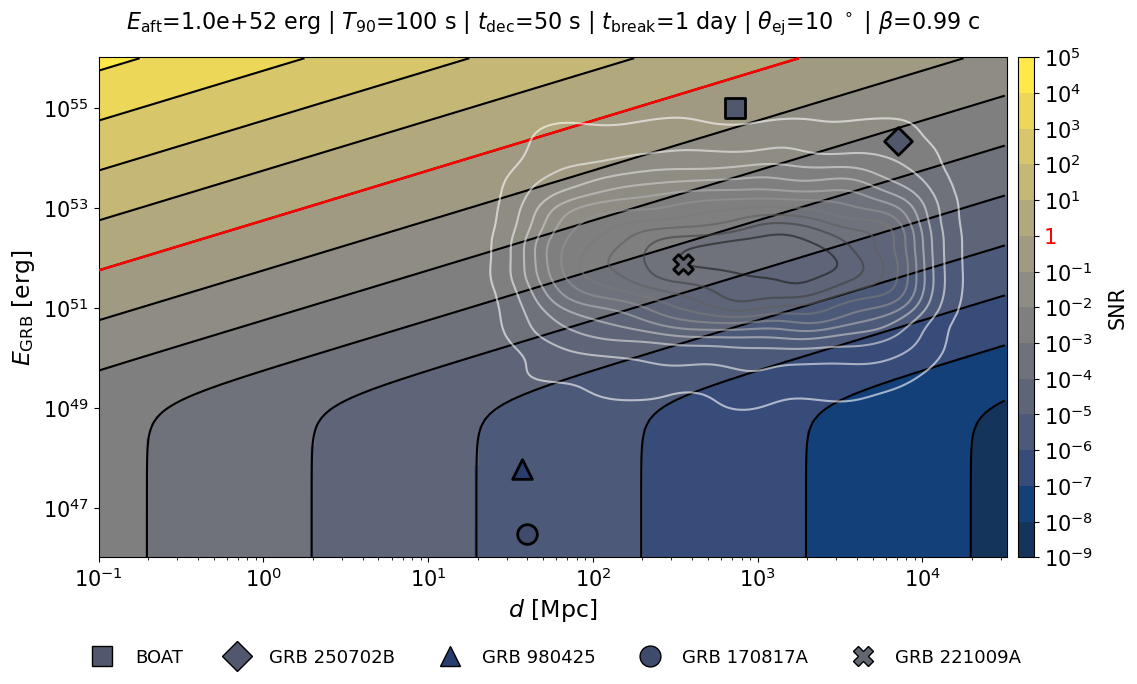

<Axes: title={'center': '$E_{\\rm{aft}}$=1.0e+52 erg | $T_{90}$=100 s | $t_{\\rm dec}$=50 s | $t_{\\rm break}$=1 day | $\\theta_{\\rm ej}$=10 $^\\circ$ | $\\beta$=0.99 c'}, xlabel='$d$ [Mpc]', ylabel='$E_{\\rm{GRB}}$ [erg]'>

In [ ]:
plot_snr_heatmap_with_kde_and_grbs(
    snr_csv_path="results_snr_heatmap_grb_newmodel/SNR_heatmap_r_E_grb.csv",
    kde_path="grb_pop_kde2d/d_E_grb_kde2d.joblib",
    x_key="r", y_key="E_grb",
    grb_params_data=grb_params_data,
    fixed_params=fixed_params,
    grb_markers={"BOAT": 's', "GRB 250702B": 'D', "GRB 980425": '^', "GRB 170817A": 'o', "GRB 211211A": 'X'}
)

key changed
x range: 0.7 - 1.0
y range: 0.0 - 90.0


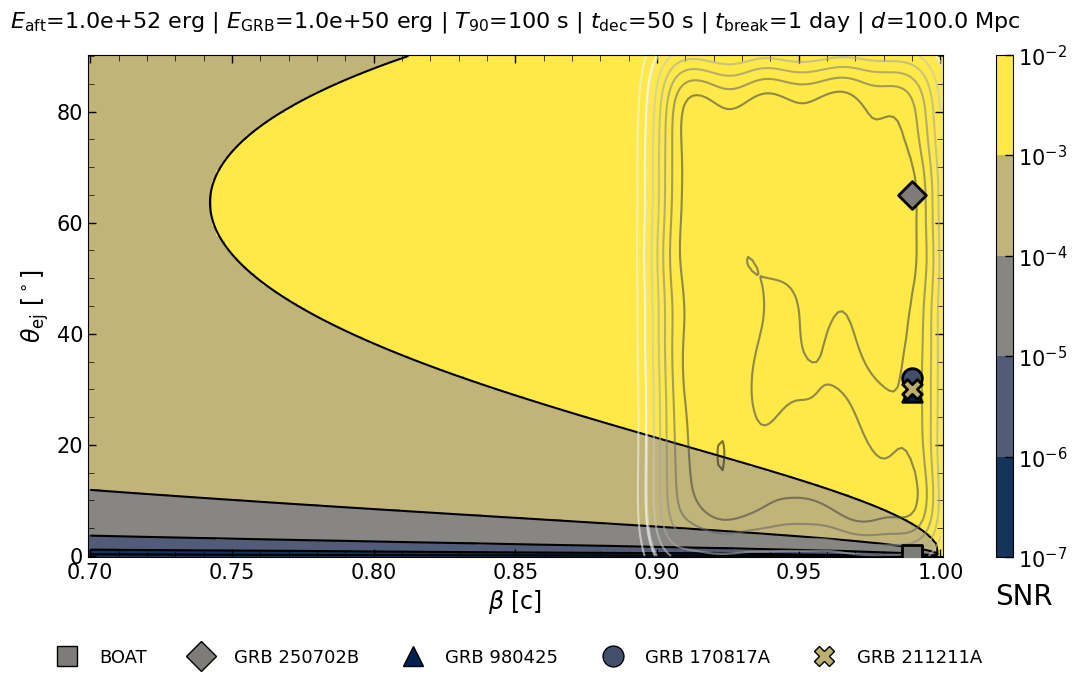

<Axes: title={'center': '$E_{\\rm{aft}}$=1.0e+52 erg | $E_{\\rm{GRB}}$=1.0e+50 erg | $T_{90}$=100 s | $t_{\\rm dec}$=50 s | $t_{\\rm break}$=1 day | $d$=100.0 Mpc'}, xlabel='$\\beta$ [c]', ylabel='$\\theta_{\\rm ej}$ [$^\\circ$]'>

In [38]:
fixed_params = {'E_aft': 1e52, 'E_grb': 1e50, 'T_90': 100, 't_dec': 50, 't_jet_break': 1*86400, 'r': 1e8, 'beta': 0.99}
plot_snr_heatmap_with_kde_and_grbs(
    snr_csv_path="results_snr_heatmap_grb_newmodel/SNR_heatmap_beta_theta.csv",
    kde_path="grb_pop_kde2d/beta_theta_kde2d.joblib",
    x_key="beta", y_key="theta",
    grb_params_data=grb_params_data,
    fixed_params=fixed_params,
    grb_markers={"BOAT": 's', "GRB 250702B": 'D', "GRB 980425": '^', "GRB 170817A": 'o', "GRB 211211A": 'X'},
    xscale='linear', yscale='linear'
)

In [28]:
def plot_double_snr_heatmap_with_kde_and_grbs(
    snr_csv_path1, kde_path1, x_key1, y_key1, grb_params_data1, fixed_params1,
    snr_csv_path2, kde_path2, x_key2, y_key2, grb_params_data2, fixed_params2,
    grb_markers1=None, grb_markers2=None,
    xscale1='log', yscale1='log', xlim1=None, ylim1=None,
    xscale2='log', yscale2='log', xlim2=None, ylim2=None
):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    import joblib
    from matplotlib.lines import Line2D

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Fusionner les fixed_params et retirer les x/y de chaque panel
    all_keys = set(fixed_params1.keys()).union(fixed_params2.keys())
    exclude_keys = {}
    title_params = []
    for k in all_keys:
        if k in exclude_keys:
            continue
        # Prendre la valeur de fixed_params1 si présente, sinon fixed_params2
        v = fixed_params1.get(k, fixed_params2.get(k))
        name = param_grb_names_latex.get(k, k)
        unit = param_grb_units.get(k, '')
        if k in ['theta', 'theta_j', 'phi_ej']:
            val_str = f"{np.rad2deg(v):.0f}"
        elif k == 'r':
            val_str = f"{v/1e6:.1f}"
        elif k == 't_jet_break' and v >= 86400:
            val_str = f"{v/86400:.0f}"
        elif isinstance(v, float) and (v < 1e-3 or v > 1e3):
            val_str = f"{v:.1e}"
        elif k == 'beta':
            val_str = f"{v:.2f}"
        else:
            val_str = f"{v:.0f}" if isinstance(v, float) else str(v)
        title_params.append(f"{name}={val_str} {unit}")
    common_title = " | ".join(title_params)
    plt.suptitle(common_title, fontsize=20, y=1.05)

    for idx, (
        snr_csv_path, kde_path, x_key, y_key, grb_params_data, fixed_params,
        grb_markers, xscale, yscale, xlim, ylim
    ) in enumerate([
        (snr_csv_path1, kde_path1, x_key1, y_key1, grb_params_data1, fixed_params1, grb_markers1, xscale1, yscale1, xlim1, ylim1),
        (snr_csv_path2, kde_path2, x_key2, y_key2, grb_params_data2, fixed_params2, grb_markers2, xscale2, yscale2, xlim2, ylim2)
    ]):
        ax = axes[idx]
        # --- Copie du code de plot_snr_heatmap_with_kde_and_grbs, mais avec ax=axes[idx] ---
        df = pd.read_csv(snr_csv_path, index_col=0)
        x_vals = df.columns.astype(float).values
        y_vals = df.index.astype(float).values

        if x_key in ["theta", "theta_j", "phi_ej"]:
            x_vals = np.rad2deg(x_vals)
        if y_key in ["theta", "theta_j", "phi_ej"]:
            y_vals = np.rad2deg(y_vals)
        if x_key in ["r"]:
            x_vals = x_vals / 1e6
        if y_key in ["r"]:
            y_vals = y_vals / 1e6
        if x_key in ['t_jet_break']:
            x_vals = x_vals / 86400
        if y_key in ['t_jet_break']:
            y_vals = y_vals / 86400

        snr_grid = df.values
        discrete_cmap, norm, ticks, ticklabels, bounds, contour_levels = make_discrete_cmap(snr_grid, 'cividis')

        kde = joblib.load(kde_path)
        gx = np.log10(x_vals) if xscale == 'log' else x_vals
        gy = np.log10(y_vals) if yscale == 'log' else y_vals
        X, Y = np.meshgrid(gx, gy)
        positions = np.vstack([X.ravel(), Y.ravel()])
        Z_kde = kde(positions).reshape(X.shape)

        im = ax.pcolormesh(x_vals, y_vals, snr_grid, cmap=discrete_cmap, norm=norm, shading='auto', alpha=0.92)
        ax.contour(x_vals, y_vals, snr_grid, levels=contour_levels, colors='k', linewidths=1.5)
        ax.contour(x_vals, y_vals, snr_grid, levels=[1], colors='red', linewidths=1.8, zorder=11)
        if xscale == 'log':
            ax.contour(10**X, 10**Y, Z_kde, levels=10, cmap='Greys', linewidths=1.5, alpha=0.6)
        else:
            ax.contour(X, Y, Z_kde, levels=10, cmap='Greys', linewidths=1.5, alpha=0.6)
        # Contour 99% KDE
        Z_kde_flat = Z_kde.flatten()
        Z_kde_sorted = np.sort(Z_kde_flat)[::-1]
        cumsum = np.cumsum(Z_kde_sorted)
        cumsum /= cumsum[-1]
        try:
            kde_99_level = Z_kde_sorted[np.searchsorted(cumsum, 0.99)]
        except Exception:
            kde_99_level = Z_kde_sorted[-1]
        kde_cmap = plt.get_cmap('Greys')
        min_kde_color = kde_cmap(0.0)
        if xscale == 'log':
            ax.contour(10**X, 10**Y, Z_kde, levels=[kde_99_level], colors=[min_kde_color], linewidths=1.5, linestyles='-', zorder=12, alpha=0.6)
        else:
            ax.contour(X, Y, Z_kde, levels=[kde_99_level], colors=[min_kde_color], linewidths=1.5, linestyles='-', zorder=12, alpha=0.6)

        # Points GRB
        if grb_markers is not None:
            legend_handles = []
            for name, params in grb_params_data.items():
                marker = grb_markers.get(name, 'o') if grb_markers else 'o'
                x_val = params[x_key]
                y_val = params[y_key]
                snr_val = params['snr']
                if x_key in ["theta", "theta_j", "phi_ej"]:
                    x_val = np.rad2deg(x_val)
                if y_key in ["theta", "theta_j", "phi_ej"]:
                    y_val = np.rad2deg(y_val)
                if x_key in ["t_jet_break"]:
                    x_val = x_val / 86400
                if y_key in ["t_jet_break"]:
                    y_val = y_val / 86400
                color = discrete_cmap(norm(snr_val))
                ax.scatter(x_val, y_val, marker=marker, s=200, c=[color], edgecolors='black', zorder=10, linewidths=2)
                legend_handles.append(Line2D([0], [0], marker=marker, color='w', markerfacecolor=color,
                                             markeredgecolor='black', markersize=15, linestyle='None', label=name, linewidth=2))
        ax.set_xscale(xscale)
        ax.set_yscale(yscale)
        ax.tick_params(axis='x', labelsize=18)
        ax.tick_params(axis='y', labelsize=18)
        x_label = param_grb_names_latex.get(x_key, x_key)
        if x_key in param_grb_units:
            x_label += f" [{param_grb_units[x_key]}]"
        y_label = param_grb_names_latex.get(y_key, y_key)
        if y_key in param_grb_units:
            y_label += f" [{param_grb_units[y_key]}]"
        ax.set_xlabel(x_label, fontsize=22)
        ax.set_ylabel(y_label, fontsize=22)
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
        # cbar
        cbar = fig.colorbar(im, ax=ax, ticks=ticks, pad=0.05, aspect=30)
        cbar.set_label("SNR", fontsize=20, labelpad=-10, rotation=0, y=-0.05, va='top', ha='right')
        cbar.ax.tick_params(labelsize=16)
        cbar.ax.set_yticklabels(ticklabels)
        for tick in cbar.ax.get_yticklabels():
            if tick.get_text() in ["$10^{0}$", "1.0", "1"]:
                tick.set_color('red')
                tick.set_text("1")
        all_handles = []
        for name in grb_params_data1.keys():
            marker = (grb_markers1 or {}).get(name, 'o')
        
            handle = Line2D([0], [0], marker=marker, color='w', markerfacecolor='grey',
                            markeredgecolor='black', markersize=15, linestyle='None', label=name, linewidth=2)
            all_handles.append(handle)
        fig.legend(all_handles, [h.get_label() for h in all_handles], loc='lower center', fontsize=13, frameon=False, ncol=len(all_handles), bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout()
    plt.show()
    return axes

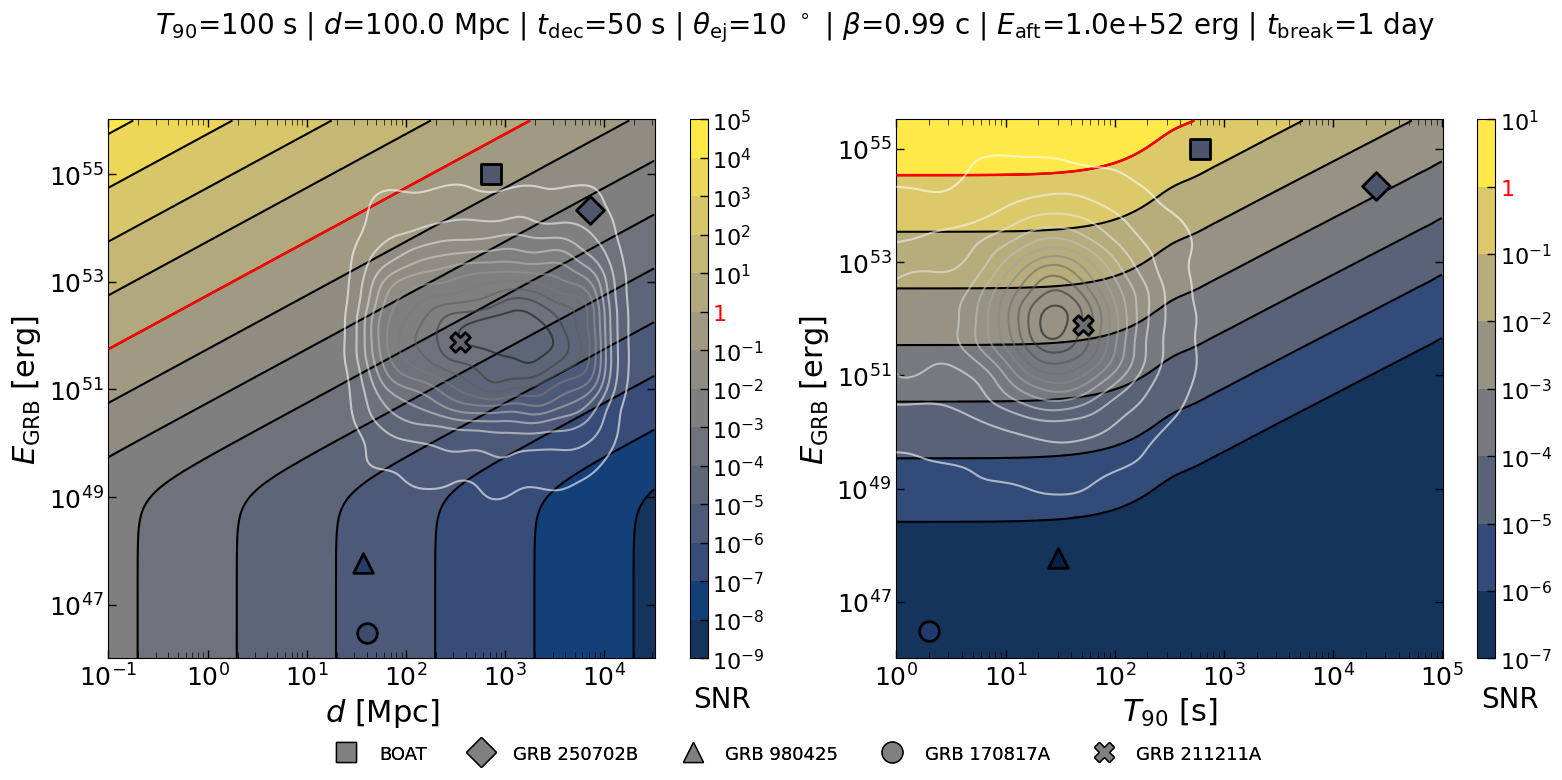

array([<Axes: xlabel='$d$ [Mpc]', ylabel='$E_{\\rm{GRB}}$ [erg]'>,
       <Axes: xlabel='$T_{90}$ [s]', ylabel='$E_{\\rm{GRB}}$ [erg]'>],
      dtype=object)

In [29]:
plot_double_snr_heatmap_with_kde_and_grbs(
    snr_csv_path1="results_snr_heatmap_grb_newmodel/SNR_heatmap_r_E_grb.csv",
    kde_path1="grb_pop_kde2d/d_E_grb_kde2d.joblib",
    x_key1="r", y_key1="E_grb",
    grb_params_data1=grb_params_data,
    grb_markers1={"BOAT": 's', "GRB 250702B": 'D', "GRB 980425": '^', "GRB 170817A": 'o', "GRB 211211A": 'X'},
    fixed_params1={'E_aft': 1e52, 'T_90': 100, 't_dec': 50, 't_jet_break': 1*86400, 'theta': np.deg2rad(10), 'beta': 0.99},
    
    snr_csv_path2="results_snr_heatmap_grb_newmodel/SNR_heatmap_T_90_E_grb.csv",
    kde_path2="grb_pop_kde2d/T90_E_grb_kde2d.joblib",
    x_key2="T_90", y_key2="E_grb",
    grb_params_data2=grb_params_data,
    grb_markers2={"BOAT": 's', "GRB 250702B": 'D', "GRB 980425": '^', "GRB 170817A": 'o', "GRB 211211A": 'X'},
    fixed_params2={'E_aft': 1e52, 'r': 1e8, 't_dec': 50, 't_jet_break': 1*86400, 'theta': np.deg2rad(10), 'beta': 0.99},

    xscale1='log', yscale1='log', xlim1=None, ylim1=None,
    xscale2='log', yscale2='log', xlim2=None, ylim2=None,
)

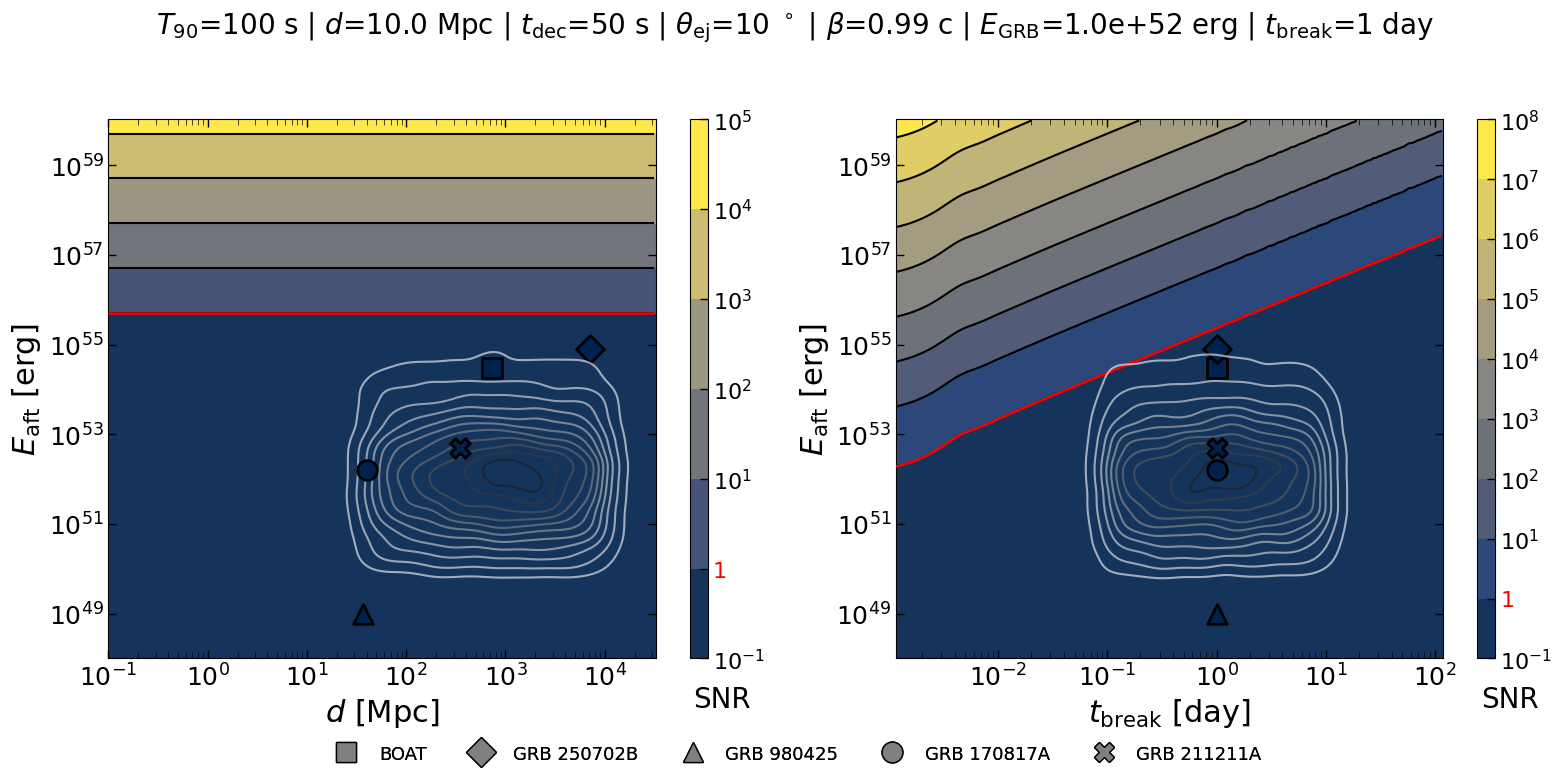

array([<Axes: xlabel='$d$ [Mpc]', ylabel='$E_{\\rm{aft}}$ [erg]'>,
       <Axes: xlabel='$t_{\\rm break}$ [day]', ylabel='$E_{\\rm{aft}}$ [erg]'>],
      dtype=object)

In [30]:
plot_double_snr_heatmap_with_kde_and_grbs(
    snr_csv_path1="results_snr_heatmap_grb_newmodel/SNR_heatmap_d_E_aft.csv",
    kde_path1="grb_pop_kde2d/d_E_aft_kde2d.joblib",
    x_key1="r", y_key1="E_aft",
    grb_params_data1=grb_params_data,
    grb_markers1={"BOAT": 's', "GRB 250702B": 'D', "GRB 980425": '^', "GRB 170817A": 'o', "GRB 211211A": 'X'},
    fixed_params1={'E_grb': 1e52, 'T_90': 100, 't_dec': 50, 't_jet_break': 1*86400, 'theta': np.deg2rad(10), 'beta': 0.99},
    
    snr_csv_path2="results_snr_heatmap_grb_newmodel/SNR_heatmap_t_jet_break_E_aft.csv",
    kde_path2="grb_pop_kde2d/t_break_E_aft_kde2d.joblib",
    x_key2="t_jet_break", y_key2="E_aft",
    grb_params_data2=grb_params_data,
    grb_markers2={"BOAT": 's', "GRB 250702B": 'D', "GRB 980425": '^', "GRB 170817A": 'o', "GRB 211211A": 'X'},
    fixed_params2={'E_grb': 5e52, 'r': 1e7, 't_dec': 50, 't_jet_break': 1*86400, 'theta': np.deg2rad(10), 'beta': 0.99},

    xscale1='log', yscale1='log', xlim1=None, ylim1=None,
    xscale2='log', yscale2='log', xlim2=None, ylim2=None,
)

---

### Special case for t_dec vs t_jet_break

In [34]:
def make_discrete_cmap_and_norm(snr_grid, base_cmap_name='cividis'):
    # Filtrage des valeurs strictement positives pour le log
    valid_snr = snr_grid[snr_grid > 0]
    if len(valid_snr) == 0: # Sécurité
        return plt.get_cmap(base_cmap_name), None, [0, 1], [0, 1], ["0", "1"]
        
    snr_min, snr_max = np.nanmin(valid_snr), np.nanmax(snr_grid)
    exp_min = int(np.floor(np.log10(snr_min)))
    exp_max = int(np.ceil(np.log10(snr_max)))

    # Détermination des bornes (log-découpées)
    bounds_raw = []

    for e in range(exp_min, exp_max + 1):
        for m in [1, 5]:
            val = m * 10**e
            # On garde une marge pour inclure les ticks proches des bords
            if snr_min * 0.9 <= val <= snr_max * 1.1:
                bounds_raw.append(val)
    
    # Nettoyage et tri des bornes
    bounds = sorted(list(set([snr_min] + bounds_raw + [snr_max])))
    n_bins = len(bounds) - 1
    
    # 2. Création de la colormap
    base_cmap = plt.get_cmap(base_cmap_name)
    colors = base_cmap(np.linspace(0, 1, n_bins))
    discrete_cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, ncolors=n_bins)

    # On utilise exactement les bounds
    ticks = bounds
    
    # Formatage intelligent pour éviter les doublons 
    ticklabels = []
    for t in ticks:
        if np.isclose(t, 1, atol=1e-2):
            ticklabels.append("1")
        elif t >= 1e4 or t < 1e-2:
            ticklabels.append(f"{t:.1e}") # Plus de précision pour les petits chiffres
        elif t >= 1:
            ticklabels.append(f"{t:.1g}")
        else:
            ticklabels.append(f"{t:.2g}") # .2g évite que 0.00034 et 0.00026 deviennent tous deux 3e-4
    print(f"Bounds: {bounds}")
    print(f"Ticks: {ticks}")
    return discrete_cmap, norm, bounds, ticks, ticklabels

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D



def plot_snr_heatmap_with_kde_and_grbs_v2(
    snr_csv_path, kde_path, x_key, y_key, grb_params_data, fixed_params,
    grb_markers=None, xscale='log', yscale='log'
):
    # Charger SNR
    df = pd.read_csv(snr_csv_path, index_col=0)
    x_vals = df.columns.astype(float).values
    y_vals = df.index.astype(float).values
    snr_grid = df.values

    # Masque pour ne garder que y > x
    X, Y = np.meshgrid(x_vals, y_vals)
    mask = Y < X
    snr_grid_masked = np.where(mask, snr_grid, np.nan)

    # Colormap discrète et ticks
    discrete_cmap, norm, bounds, ticks, ticklabels = make_discrete_cmap_and_norm(snr_grid_masked, 'Greens_r')

    # Charger la KDE
    kde = joblib.load(kde_path)
    gx = np.log10(x_vals)
    gy = np.log10(y_vals)
    Xlog, Ylog = np.meshgrid(gx, gy)
    positions = np.vstack([Xlog.ravel(), Ylog.ravel()])
    Z_kde = kde(positions).reshape(Xlog.shape)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.pcolormesh(x_vals, y_vals, snr_grid_masked, cmap=discrete_cmap, norm=norm, shading='auto', alpha=0.92)
    # Contours SNR (noirs)
    cs = ax.contour(x_vals, y_vals, snr_grid_masked, levels=bounds, colors='k', linewidths=1.2)
    # Contour SNR=1 (rouge épais)
    ax.contour(x_vals, y_vals, snr_grid_masked, levels=[1], colors='red', linewidths=2.2, zorder=11)
    # KDE
    ax.contour(10**Xlog, 10**Ylog, Z_kde, levels=10, cmap='Greys', linewidths=1.2, alpha=0.6)

    # Points GRB
    legend_handles = []
    if grb_markers:
        for name, params in grb_params_data.items():
            marker = grb_markers.get(name, 'o')
            x_val = params[x_key]
            y_val = params[y_key]
            snr_val = params['snr']
            # Conversion angle si besoin
            if x_key in ["theta", "theta_j", "phi_ej"]:
                x_val = np.rad2deg(x_val)
            if y_key in ["theta", "theta_j", "phi_ej"]:
                y_val = np.rad2deg(y_val)
            # Ne plot que si y > x
            if y_val > x_val:
                color = discrete_cmap(norm(snr_val))
                ax.scatter(x_val, y_val, marker=marker, s=160, c=[color], edgecolors='black', zorder=10, linewidths=2)
                legend_handles.append(Line2D([0], [0], marker=marker, color='w', markerfacecolor=color,
                                             markeredgecolor='black', markersize=12, linestyle='None', label=name, linewidth=2))

    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    # Labels axes
    x_label = param_grb_names_latex.get(x_key, x_key)
    if x_key in param_grb_units:
        x_label += f" [{param_grb_units[x_key]}]"
    y_label = param_grb_names_latex.get(y_key, y_key)
    if y_key in param_grb_units:
        y_label += f" [{param_grb_units[y_key]}]"
    ax.set_xlabel(x_label, fontsize=20)
    ax.set_ylabel(y_label, fontsize=20)
    # Titre automatique avec params fixes (hors x/y)
    title_params = []
    for k, v in fixed_params.items():
        if k in [x_key, y_key]:
            continue
        name = param_grb_names_latex.get(k, k)
        unit = param_grb_units.get(k, '')
        if k in ['theta', 'theta_j', 'phi_ej']:
            val_str = f"{np.rad2deg(v):.0f}"
        elif k == 'r':
            val_str = f"{v/1e6:.1f}"
        elif k == 't_jet_break' and v >= 86400:
            val_str = f"{v/86400:.0f}"
        elif isinstance(v, float) and (v < 1e-3 or v > 1e3):
            val_str = f"{v:.1e}"
        elif k == 'beta':
            val_str = f"{v:.2f}"
        else:
            val_str = f"{v:.0f}" if isinstance(v, float) else str(v)
        title_params.append(f"{name}={val_str} {unit}")
    title = " | ".join(title_params)
    ax.set_title(title, fontsize=18, pad=20)

    # Colorbar discrète, ticks uniformes
    cbar = fig.colorbar(im, ax=ax, ticks=ticks, spacing='uniform', pad=0.05, aspect=30)
    cbar.ax.set_yticklabels(ticklabels)
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label("SNR", fontsize=20, labelpad=-10, rotation=0, y=-0.05, va='top', ha='right')
    # Highlight tick SNR=1 en rouge
    for tick, label in zip(cbar.ax.get_yticklabels(), ticks):
        if np.isclose(label, 1, atol=0.01):
            tick.set_color('red')


    # Isolignes y = x - delta_t
    delta_ts = [60, 3600, 86400]  # 1min, 1h, 1j
 
    ls = [':', '--', '-.']
    labels = ['1 min', '1 h', '1 day']
    x_plot = np.logspace(np.log10(np.nanmin(x_vals)), np.log10(np.nanmax(x_vals)), 9_000_000)
    for dt, l, label in zip(delta_ts, ls, labels):
        y_plot = x_plot - dt
        mask_line = (y_plot >= np.nanmin(y_vals)) & (y_plot <= np.nanmax(y_vals))
        ax.plot(x_plot[mask_line], y_plot[mask_line], color='darkorange', linestyle=l, linewidth=2, label=f'{label}')

    # Légende
    handles, legend_labels = ax.get_legend_handles_labels()
    unique = dict(zip(legend_labels, handles))
    ax.legend(unique.values(), unique.keys(), loc='upper left', fontsize=12)

    plt.tight_layout()
    plt.show()
    return ax

Bounds: [np.float64(0.0002609830672013), 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, np.float64(2.923355000137659)]
Ticks: [np.float64(0.0002609830672013), 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, np.float64(2.923355000137659)]


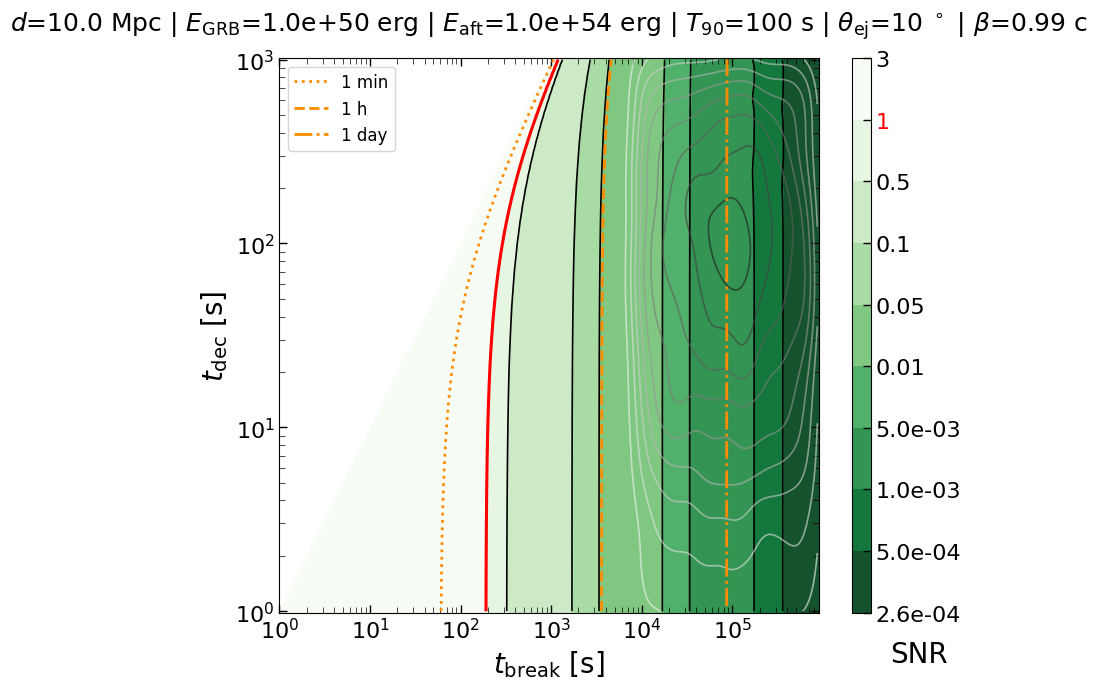

<Axes: title={'center': '$d$=10.0 Mpc | $E_{\\rm{GRB}}$=1.0e+50 erg | $E_{\\rm{aft}}$=1.0e+54 erg | $T_{90}$=100 s | $\\theta_{\\rm ej}$=10 $^\\circ$ | $\\beta$=0.99 c'}, xlabel='$t_{\\rm break}$ [s]', ylabel='$t_{\\rm dec}$ [s]'>

In [42]:
fixed_params = {'r': 10 * 1e6,  # 100 Mpc
        'E_grb': 1e50,
        'E_aft': 1e54,
        'T_90': 100,
        'theta': np.deg2rad(10),
        'beta': 0.99,
        }

plot_snr_heatmap_with_kde_and_grbs_v2(
    snr_csv_path="results_snr_heatmap_grb_newmodel/SNR_heatmap_t_jet_break_t_dec.csv",
    kde_path="grb_pop_kde2d/t_break_t_dec_kde2d.joblib",
    x_key="t_jet_break", y_key="t_dec",
    grb_params_data=grb_params_data,
    fixed_params=fixed_params,
    grb_markers=None
)